Logistic Regression

In [4]:

# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix
)

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pickle


In [5]:

# Load Dataset

train_df = pd.read_csv('Titanic_train.csv')
test_df = pd.read_csv('Titanic_test.csv')

print(train_df.head())
print(train_df.info())


   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

In [6]:

# Missing Values

print(train_df.isnull().sum())

# Fill Missing Values
train_df['Age'].fillna(train_df['Age'].median(), inplace=True)
train_df['Embarked'].fillna(train_df['Embarked'].mode()[0], inplace=True)
train_df['Fare'].fillna(train_df['Fare'].median(), inplace=True)


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


C:\Users\Raja\AppData\Local\Temp\ipykernel_12804\2490025505.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  train_df['Age'].fillna(train_df['Age'].median(), inplace=True)
C:\Users\Raja\AppData\Local\Temp\ipykernel_12804\2490025505.py:7: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chaine

0       7.2500
1      71.2833
2       7.9250
3      53.1000
4       8.0500
        ...   
886    13.0000
887    30.0000
888    23.4500
889    30.0000
890     7.7500
Name: Fare, Length: 891, dtype: float64

In [7]:

# Encode Categorical Variables

label_encoder = LabelEncoder()

train_df['Sex'] = label_encoder.fit_transform(train_df['Sex'])
train_df['Embarked'] = label_encoder.fit_transform(train_df['Embarked'])


In [8]:

# Outlier Treatment using IQR

Q1 = train_df['Fare'].quantile(0.25)
Q3 = train_df['Fare'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

train_df = train_df[(train_df['Fare'] >= lower) &
                    (train_df['Fare'] <= upper)]

print("Outliers Removed Successfully")


Outliers Removed Successfully


In [12]:
# Multicollinearity Check using VIF

from statsmodels.stats.outliers_influence import variance_inflation_factor

features = ['Pclass', 'Sex', 'Age', 'Fare', 'SibSp', 'Parch']

X = train_df[features]

# Remove infinite values
X = X.replace([np.inf, -np.inf], np.nan)

# Fill missing values
X = X.fillna(X.mean())

# Check again
print(X.isnull().sum())

# Calculate VIF
vif_data = pd.DataFrame()

vif_data["Feature"] = X.columns

vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif_data)

Pclass    0
Sex       0
Age       0
Fare      0
SibSp     0
Parch     0
dtype: int64
  Feature       VIF
0  Pclass  5.385264
1     Sex  3.396490
2     Age  6.003612
3    Fare  3.685297
4   SibSp  1.944016
5   Parch  1.690850


In [13]:

# Feature Scaling

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

y = train_df['Survived']


In [14]:

# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)


In [15]:

# Logistic Regression Model

model = LogisticRegression()

model.fit(X_train, y_train)

print("Model Trained Successfully")


Model Trained Successfully


In [16]:

# Predictions

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]


In [17]:

# Evaluation Metrics

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


Accuracy: 0.7483870967741936
Precision: 0.7142857142857143
Recall: 0.5833333333333334
F1 Score: 0.6422018348623854
ROC-AUC: 0.7859649122807016


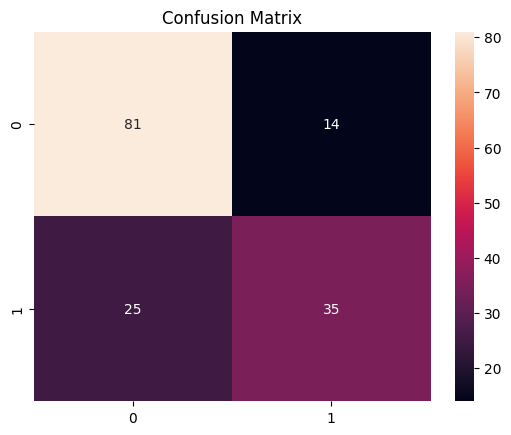

In [18]:

# Confusion Matrix

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.show()


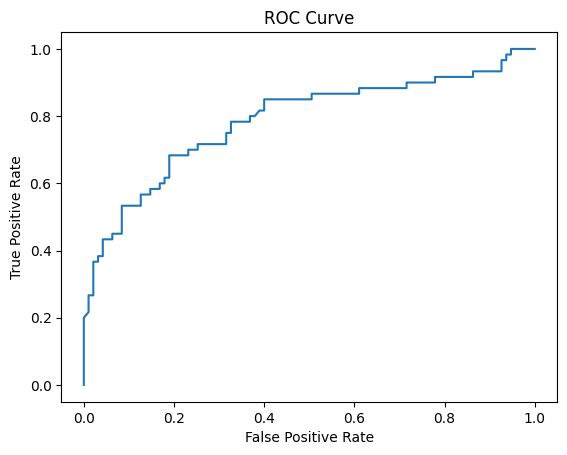

In [19]:

# ROC Curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()


In [20]:

# Save Model

with open('logistic_model.pkl', 'wb') as file:
    pickle.dump(model, file)

with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

print("Model Saved Successfully")


Model Saved Successfully


In [ ]:

import streamlit as st
import pickle
import numpy as np

model = pickle.load(open('logistic_model.pkl', 'rb'))
scaler = pickle.load(open('scaler.pkl', 'rb'))

st.title('Titanic Survival Prediction')

pclass = st.selectbox('Passenger Class', [1,2,3])
sex = st.selectbox('Sex', ['Male', 'Female'])
age = st.number_input('Age', value=25)
fare = st.number_input('Fare', value=50.0)
sibsp = st.number_input('Siblings/Spouses', value=0)
parch = st.number_input('Parents/Children', value=0)

sex = 1 if sex == 'Male' else 0

if st.button('Predict'):
    
    input_data = np.array([[pclass, sex, age, fare, sibsp, parch]])
    
    input_scaled = scaler.transform(input_data)
    
    prediction = model.predict(input_scaled)
    
    if prediction[0] == 1:
        st.success('Passenger is likely to survive')
    else:
        st.error('Passenger is not likely to survive')
